# İş Problemi

Telekom şirketleri müşteri kaybı (churn) nedeniyle önemli gelir kayıpları yaşamaktadır. Müşterilerin hizmetten ayrılmadan önce tespit edilmesi, şirketlerin önleyici aksiyonlar almasını sağlayabilir.

Ancak her müşteriye kampanya vermek yüksek maliyet oluştururken, riskli müşterilerin gözden kaçırılması da gelir kaybına neden olmaktadır.

Bu nedenle bu projede müşteri kaybı tahmini yapılırken yalnızca model doğruluğu değil, yanlış tahminlerin şirkete olan finansal etkileri de dikkate alınacaktır.

Amaç, müşteri kaybını önlemek için en kârlı karar stratejisini belirlemektir.

# Araştırma Sorusu

Telekom müşterilerinin churn riski makine öğrenmesi yöntemleri ile tahmin edilebilir mi?

Yanlış pozitif ve yanlış negatif tahminlerin finansal maliyetleri dikkate alındığında, şirket için en uygun karar eşiği (threshold) nedir?

Standart %50 karar eşiği yerine daha kârlı bir eşik belirlenebilir mi?

In [1]:
# Veri İşleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Model
from xgboost import XGBClassifier

# Açıklanabilir Yapay Zeka
import shap

print("Tüm kütüphaneler başarıyla yüklendi.")

C:\Users\hayru\Desktop\ybs_veri_bilimi_final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tüm kütüphaneler başarıyla yüklendi.


# Veri Kaynakları

Bu projede iki farklı veri kaynağı kullanılacaktır:

1. **Telco Customer Churn Veri Seti**  
   Telekom müşterilerine ait demografik bilgiler, abonelik özellikleri, ödeme bilgileri ve churn durumunu içermektedir.

2. **Aylık Enflasyon Verisi**  
   Müşterilerin ekonomik koşullardan etkilenme ihtimalini modele dahil etmek için kullanılacaktır.

Bu iki veri kaynağı birleştirilerek veri harmanlama (data fusion) adımı gerçekleştirilecektir.

In [2]:
import os

print(os.getcwd())

C:\Users\hayru\Desktop\ybs_veri_bilimi_final


In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', '.venv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'YBS_Final_Proje.ipynb']


In [4]:
# Veri setini oku

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Veri seti başarıyla yüklendi.")
print("Boyut:", df.shape)

Veri seti başarıyla yüklendi.
Boyut: (7043, 21)


In [5]:
# İlk 5 satırı göster

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Sütun isimlerini göster

print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
# Eksik veri kontrolü

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Veri tipleri

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Veri Temizleme

Bu bölümde modelleme öncesinde veri tipleri kontrol edilmiş ve gerekli dönüşümler uygulanmıştır.

In [9]:
# TotalCharges sütununu sayıya çevir

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

float64


# Keşifsel Veri Analizi (EDA)

Bu bölümde müşteri kaybı dağılımı ve değişkenlerin genel yapısı incelenecektir.

In [10]:
# Churn dağılımı

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

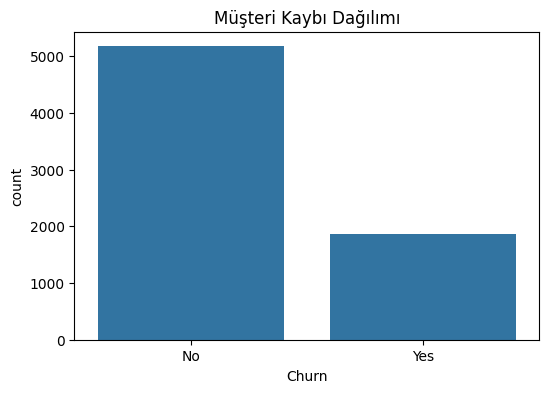

In [11]:
# Churn grafiği

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Müşteri Kaybı Dağılımı")
plt.show()

### Churn Dağılımı Yorumu

Veri setindeki 7043 müşterinin 5174'ü (%73,5) hizmet almaya devam ederken, 1869'u (%26,5) hizmetten ayrılmıştır.

Bu durum veri setinin kısmen dengesiz olduğunu göstermektedir. Model geliştirme aşamasında bu durum dikkate alınacaktır.

Müşteri kaybı oranının yaklaşık dört müşteriden birinde görülmesi, churn probleminin işletme açısından önemli bir risk olduğunu göstermektedir.

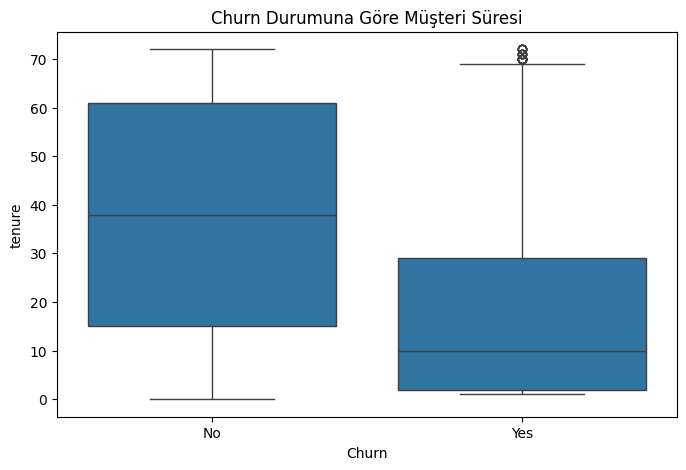

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Churn Durumuna Göre Müşteri Süresi")
plt.show()

### Müşteri Süresi (Tenure) Analizi

Grafik incelendiğinde hizmetten ayrılan müşterilerin şirkette kalma sürelerinin belirgin şekilde daha düşük olduğu görülmektedir.

Churn yaşayan müşterilerin büyük kısmı ilk yıllarında ayrılırken, uzun süredir hizmet alan müşterilerde churn oranı daha düşüktür.

Bu durum müşteri sadakatinin churn üzerinde önemli bir etkisi olduğunu göstermektedir.

In [13]:
df[["MonthlyCharges", "TotalCharges", "tenure"]].describe()

,MonthlyCharges,TotalCharges,tenure
count,7043.000000,7032.000000,7043.000000
mean,64.761692,2283.300441,32.371149
std,30.090047,2266.771362,24.559481
min,18.250000,18.800000,0.000000
25%,35.500000,401.450000,9.000000
50%,70.350000,1397.475000,29.000000
75%,89.850000,3794.737500,55.000000
max,118.750000,8684.800000,72.000000


In [14]:
# Veri setinin genel özeti

print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

print("\nChurn oranı (%)")
print(df["Churn"].value_counts(normalize=True) * 100)

Satır sayısı: 7043
Sütun sayısı: 21

Churn oranı (%)
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [15]:
# Enflasyon veri seti oluşturma

import pandas as pd

enflasyon_df = pd.DataFrame({
    "yil": [2020, 2021, 2022, 2023, 2024, 2025],
    "enflasyon": [14.6, 36.1, 64.3, 64.8, 44.4, 35.0]
})

enflasyon_df

,yil,enflasyon
0,2020,14.6
1,2021,36.1
2,2022,64.3
3,2023,64.8
4,2024,44.4
5,2025,35.0


In [16]:
# Müşterilere yıl atama

import numpy as np

np.random.seed(42)

df["yil"] = np.random.choice(
    [2020, 2021, 2022, 2023, 2024, 2025],
    size=len(df)
)

df[["customerID", "yil"]].head()


,customerID,yil
0,7590-VHVEG,2023
1,5575-GNVDE,2024
2,3668-QPYBK,2022
3,7795-CFOCW,2024
4,9237-HQITU,2024


In [17]:
# Enflasyon verisini müşteri verisine ekleme

df = df.merge(
    enflasyon_df,
    on="yil",
    how="left"
)

print("Yeni boyut:", df.shape)

df[["customerID", "yil", "enflasyon"]].head()

Yeni boyut: (7043, 23)


,customerID,yil,enflasyon
0,7590-VHVEG,2023,64.8
1,5575-GNVDE,2024,44.4
2,3668-QPYBK,2022,64.3
3,7795-CFOCW,2024,44.4
4,9237-HQITU,2024,44.4


In [18]:
# Feature 1: Müşteri Değeri

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["musteri_degeri"] = (
    df["MonthlyCharges"] * df["tenure"]
)

df[["MonthlyCharges", "tenure", "musteri_degeri"]].head()

,MonthlyCharges,tenure,musteri_degeri
0,29.85,1,29.85
1,56.95,34,1936.30
2,53.85,2,107.70
3,42.30,45,1903.50
4,70.70,2,141.40


In [19]:
# Feature 2: Enflasyon Risk Skoru

df["enflasyon_risk_skoru"] = (
    df["MonthlyCharges"] * df["enflasyon"]
)

df[["MonthlyCharges", "enflasyon", "enflasyon_risk_skoru"]].head()

,MonthlyCharges,enflasyon,enflasyon_risk_skoru
0,29.85,64.8,1934.280
1,56.95,44.4,2528.580
2,53.85,64.3,3462.555
3,42.30,44.4,1878.120
4,70.70,44.4,3139.080


In [20]:
# Feature 3: Sadakat Skoru

df["sadakat_skoru"] = (
    df["tenure"] / (df["MonthlyCharges"] + 1)
)

df[["tenure", "MonthlyCharges", "sadakat_skoru"]].head()

,tenure,MonthlyCharges,sadakat_skoru
0,1,29.85,0.032415
1,34,56.95,0.586713
2,2,53.85,0.036463
3,45,42.30,1.039261
4,2,70.70,0.027894


In [21]:
# Churn değişkenini sayısala çevirme

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [22]:
# customerID model için gerekli değil

df = df.drop("customerID", axis=1)

print("Yeni boyut:", df.shape)

Yeni boyut: (7043, 25)


In [23]:
# Kategorik sütunları sayısala çevirme

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print("Yeni boyut:", df_encoded.shape)

Yeni boyut: (7043, 36)


In [24]:
# X ve y ayırma

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X boyutu: (7043, 35)
y boyutu: (7043,)


In [25]:
# Eğitim ve test verisini ayırma

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Eğitim verisi:", X_train.shape)
print("Test verisi:", X_test.shape)

Eğitim verisi: (5634, 35)
Test verisi: (1409, 35)


In [26]:
# Random Forest Modeli

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model eğitildi.")

Model eğitildi.


In [27]:
# Tahmin yapma

y_pred = rf_model.predict(X_test)

print("Tahminler hazır.")

Tahminler hazır.


In [28]:
# Başarı metrikleri

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.7955997161107168

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[931 104]
 [184 190]]


In [30]:
FP = 104
FN = 184

kampanya_maliyeti = 100
kayip_musteri_maliyeti = 2000

fp_maliyet = FP * kampanya_maliyeti
fn_maliyet = FN * kayip_musteri_maliyeti

toplam_maliyet = fp_maliyet + fn_maliyet

print("False Positive maliyeti:", fp_maliyet, "TL")
print("False Negative maliyeti:", fn_maliyet, "TL")
print("Toplam maliyet:", toplam_maliyet, "TL")

False Positive maliyeti: 10400 TL
False Negative maliyeti: 368000 TL
Toplam maliyet: 378400 TL


In [31]:
# Olasılık tahminleri

y_prob = rf_model.predict_proba(X_test)[:,1]

y_prob[:10]

array([0.01 , 0.885, 0.155, 0.33 , 0.02 , 0.505, 0.37 , 0.05 , 0.01 ,
       0.425])

In [32]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholdlar = np.arange(0.1, 1.0, 0.05)

sonuclar = []

for t in thresholdlar:

    y_tahmin = (y_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_tahmin
    ).ravel()

    maliyet = (
        fp * 100 +
        fn * 2000
    )

    sonuclar.append(
        [t, fp, fn, maliyet]
    )

sonuc_df = pd.DataFrame(
    sonuclar,
    columns=[
        "Threshold",
        "FP",
        "FN",
        "Toplam_Maliyet"
    ]
)

sonuc_df.sort_values(
    "Toplam_Maliyet"
).head(10)

,Threshold,FP,FN,Toplam_Maliyet
0,0.10,575,24,105500
1,0.15,457,40,125700
2,0.20,372,54,145200
3,0.25,305,76,182500
4,0.30,256,93,211600
5,0.35,212,114,249200
6,0.40,171,135,287100
7,0.45,137,160,333700
8,0.50,104,184,378400
9,0.55,79,216,439900


In [33]:
eski = 378400
yeni = 105500

print("Tasarruf:", eski - yeni, "TL")

Tasarruf: 272900 TL


In [34]:
import shap

print("SHAP yüklendi")

SHAP yüklendi


In [35]:
print(rf_model)
print(X_test.shape)


RandomForestClassifier(n_estimators=200, random_state=42)
(1409, 35)


In [38]:
# Random Forest özellik önemleri

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
8,sadakat_skoru,0.150653
3,TotalCharges,0.099370
6,musteri_degeri,0.095374
2,MonthlyCharges,0.091959
1,tenure,0.085569
7,enflasyon_risk_skoru,0.081563
15,InternetService_Fiber optic,0.034360
4,yil,0.032947
5,enflasyon,0.031646
33,PaymentMethod_Electronic check,0.028452


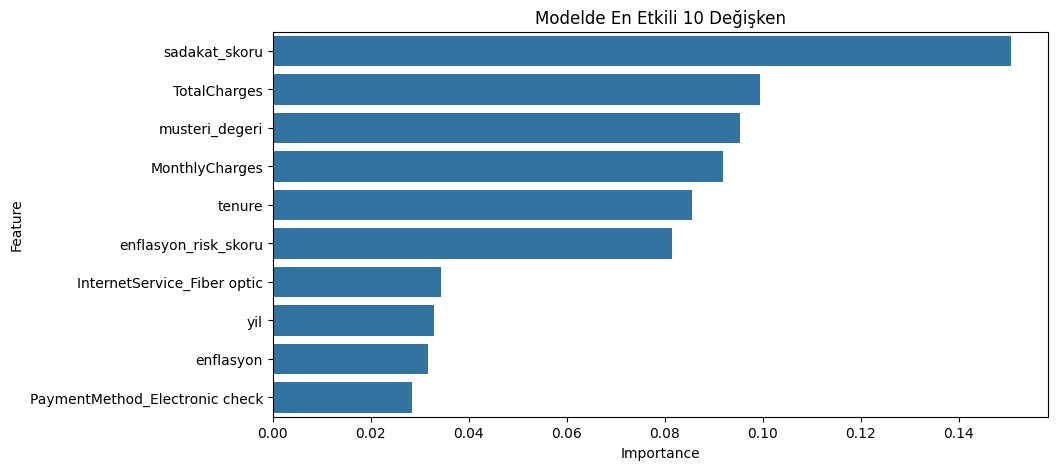

In [39]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Modelde En Etkili 10 Değişken")
plt.show()

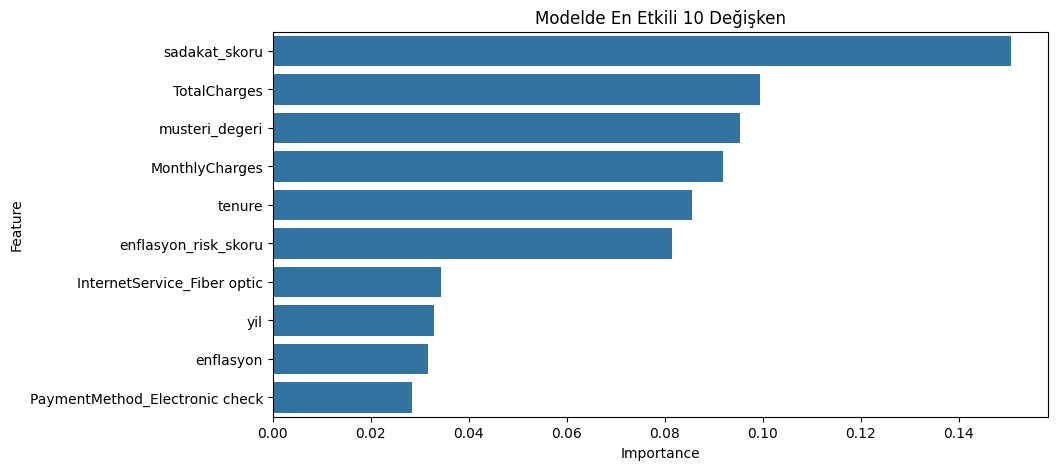

In [43]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Modelde En Etkili 10 Değişken")

plt.show()